# Example 11A: k-Nearest Neighbors (kNN)

k-Nearest Neighbor models (kNNs) are a supervised model that are simple to implement and a good example to know before diving into kernel smoothing methods for classification. The big difference between kNNs and kernel smoothers is that kNNs generally do not produce smooth decision boundaries. 

## How kNNs Work

- **Core Concept**: kNN works by identifying the `k` closest training examples to a given point and making predictions based on these nearby points.
- **Versatility**: Used for both classification (kNN Classification) and regression (kNN Regression).
- **Hyperparameter (k)**: The choice of `k` (the number of neighbors) is crucial. A smaller `k` makes the model sensitive to noise, whereas a larger `k` might smooth over important details.
- **Distance Metric**: The distance (Euclidean, Manhattan, etc.) is used to determine the closest neighbors.
- **Pros and Cons**: Simple to understand and implement, but can become inefficient as dataset size grows, especially in higher dimensions.


In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# For dataset creation
from sklearn.datasets import make_classification

# For model and evaluation
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score

Because we are interested in creating classes, we use the function `make_classification` to generate this dataset from the Scikit-Learn package. 

In [2]:
# Generate synthetic data
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_classes=3,
    n_informative=2,  # Number of informative features
    n_redundant=0,    # Number of redundant features
    n_clusters_per_class=1,
    random_state=11
)

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=11)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=11)

To help us understand this dataset better, let's visualize it. 

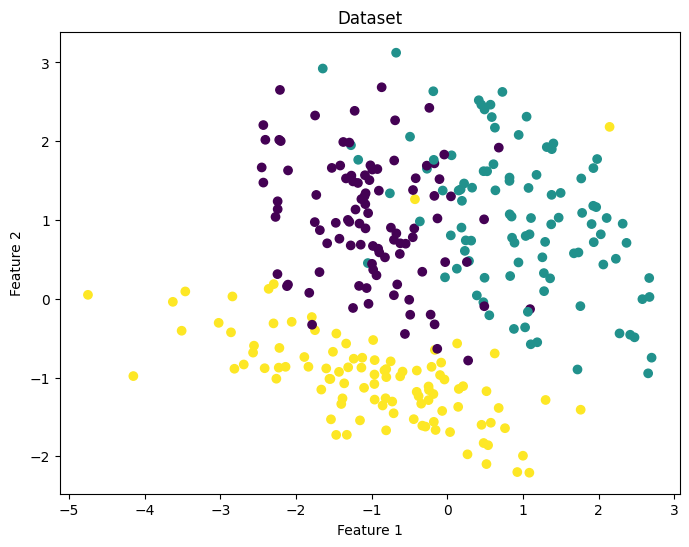

In [3]:
# Create scatter plots to visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

We know perform a standard search for the main hyperparameter, `k`. It is important to note, though, that there are several hyperparameters for this models (as well as many others). In the description above, we mention that the metric can be changed. The default is the Euclidean metric, but one could use several others. Another component to this model is providing weights to the points. For example, we could consider weights that prioritize points closer to the target than those further away. With every model introduced in this class, it is important toN take a look at the documentation: 
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

For the sake of this example, we will focus only on the values of `k`. We will use the accuracy of the validation set to make the selection. 

In [4]:
# Initialize lists to store validation set accuracy and corresponding values of k
k_values = []
validation_accuracies = []

# Try different values of k for KNN and select the best k based on validation set accuracy
for k in range(1, 21):  # Trying values of k from 1 to 20
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predict on the validation set
    y_val_pred = knn.predict(X_val)
    
    # Calculate accuracy on the validation set
    val_accuracy = accuracy_score(y_val, y_val_pred)
    
    # Append k and corresponding accuracy to lists
    k_values.append(k)
    validation_accuracies.append(val_accuracy)

# Find the best k based on validation set accuracy
best_k = k_values[np.argmax(validation_accuracies)]
print(f"Best k based on validation set accuracy: {best_k}")

Best k based on validation set accuracy: 16


To get a sense of the possible models reviewed, let's plot validation accuracy against the different possible values for `k`. The graph below suggests that both `k=16` and `k=18` would be strong models to consider. If we wish the simplest model with strong accuracy, `k=5` could be a good choice. 

For the purposes of this exercise, we will stick with the value of `k` selected above. 

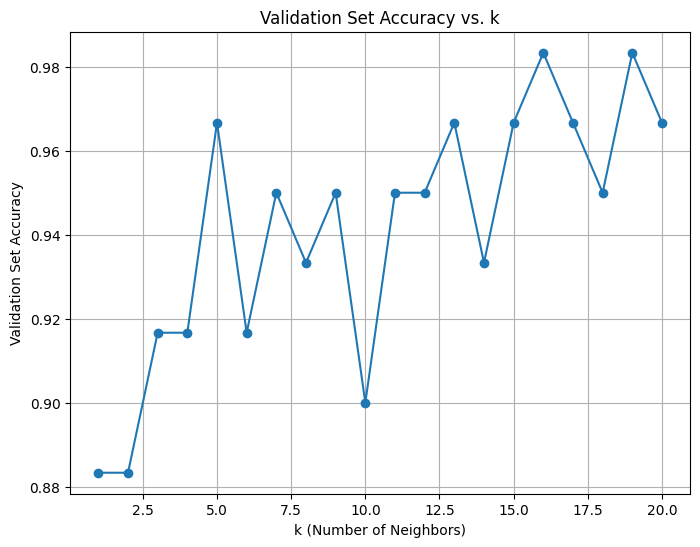

In [5]:
# Plot k values vs. validation accuracies
plt.figure(figsize=(8, 6))
plt.plot(k_values, validation_accuracies, marker='o', linestyle='-')
plt.title('Validation Set Accuracy vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Validation Set Accuracy')
plt.grid(True)
plt.show()


Now that we have selected `k`, let's construct the model using both the training and validation set. 

In [6]:
# Fit the final KNN model using the best k on the combined training and validation sets
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(np.vstack((X_train, X_val)), np.hstack((y_train, y_val)))

KNeighborsClassifier(n_neighbors=16)

We evaluate our model by studying the content of the classification report below. 

In [7]:
# Predict on the testing set
y_test_pred = final_knn.predict(X_test)

# Calculate accuracy on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on testing set with best k ({best_k}): {test_accuracy:.4f} \n")
print(classification_report(y_test, y_test_pred))

Accuracy on testing set with best k (16): 0.9333 

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       1.00      0.92      0.96        24
           2       0.92      1.00      0.96        23

    accuracy                           0.93        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.94      0.93      0.93        60



To get a better understanding of the classification report, let's graph the decision boundaries and study where our testing set falls reletive to our model. 

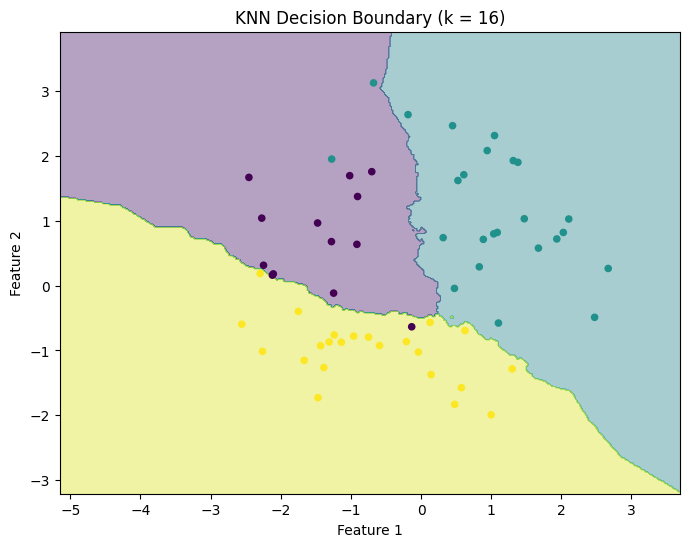

In [8]:
# Plot the best KNN model's decision boundary
plt.figure(figsize=(8, 6))
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = final_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20)
plt.title('KNN Decision Boundary (k = {})'.format(best_k))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## kNN used for Regression

As was stated earlier, kNN is a model that can also be used for regression. Let's consider the example below. 

The ground truth is $$Y = \sin(X) + \sin^2(X).$$

In [9]:
# Generate synthetic regression data
np.random.seed(11)
X = np.linspace(0, 10, 200)
y = np.sin(X) + np.sin(X)**2 + np.random.normal(0, 0.25, len(X)) 
X = X.reshape(-1, 1)

X_range = np.linspace(0, 10, 500)
y_truth = np.sin(X_range) + np.sin(X_range)**2

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=11)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=11)


When studying the dataset, we see clearly that it is nonlinear. 

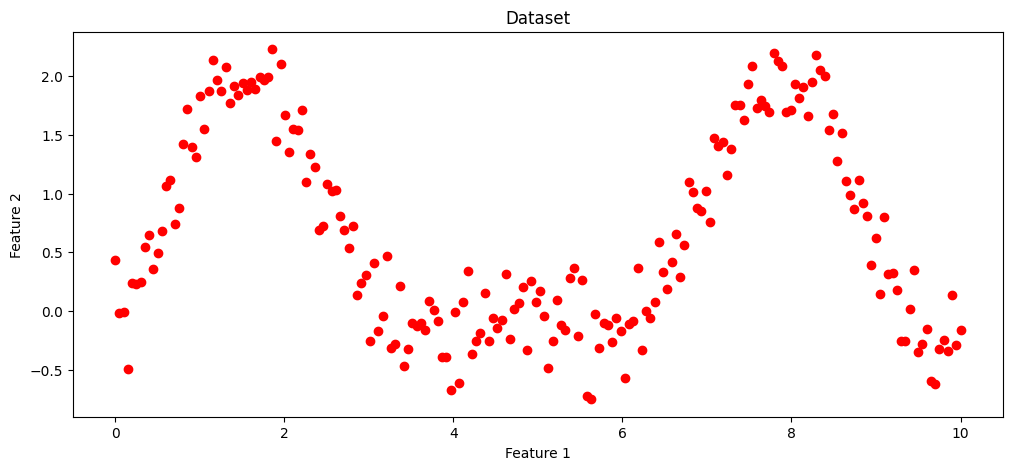

In [10]:
# Create scatter plots to visualize the data
plt.figure(figsize=(12, 5))
plt.scatter(X, y, color='red', label='Dataset')
plt.title('Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

We use our standard approach for finding an optimal `k` based on our validation set's MSE. 

In [11]:
# Initialize lists to store validation set metrics and corresponding values of k
k_values = []
validation_mse = []
validation_r2 = []

# Try different values of k for kNN regression and select the best k based on validation set metrics
for k in range(1, 30):
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
    knn_regressor.fit(X_train, y_train)
    
    # Predict on the validation set
    y_val_pred = knn_regressor.predict(X_val)
    
    # Calculate Mean Squared Error (MSE) on the validation set
    mse = mean_squared_error(y_val, y_val_pred)
    
    # Calculate R-squared (R2) on the validation set
    r2 = r2_score(y_val, y_val_pred)
    
    # Append k and corresponding metrics to lists
    k_values.append(k)
    validation_mse.append(mse)
    validation_r2.append(r2)

# Find the best k based on validation set metrics
best_k = k_values[np.argmin(validation_mse)]
print(f"Best k based on validation set MSE: {best_k}")

Best k based on validation set MSE: 9


To get a sense of all the models reviewed, we plot the metrics against the hyperparameter. 

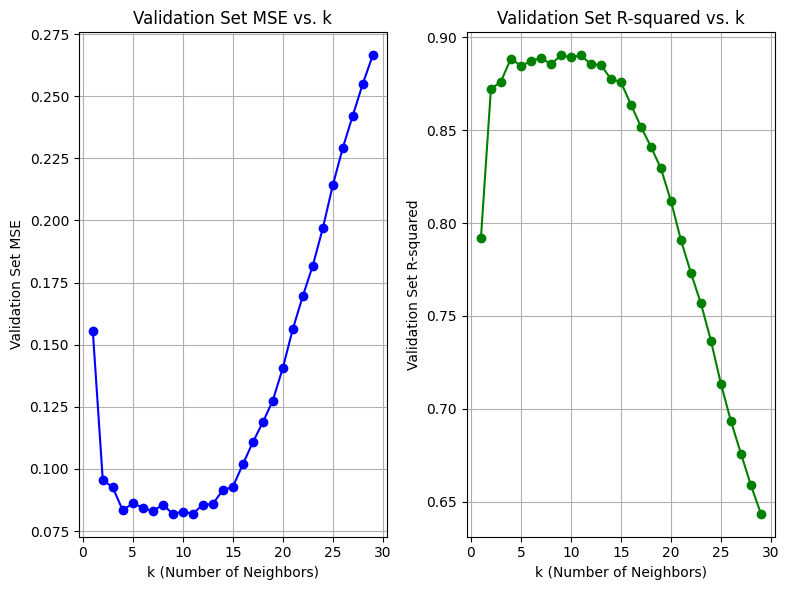

In [12]:
# Plot k values vs. validation set metrics
plt.figure(figsize=(8, 6))
plt.subplot(121)
plt.plot(k_values, validation_mse, marker='o', linestyle='-', color='blue')
plt.title('Validation Set MSE vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Validation Set MSE')
plt.grid(True)

plt.subplot(122)
plt.plot(k_values, validation_r2, marker='o', linestyle='-', color='green')
plt.title('Validation Set R-squared vs. k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Validation Set R-squared')
plt.grid(True)

plt.tight_layout()
plt.show()

Based on our selected value for `k`, we construct the final model. Remember, this model is trained on both the training and validation set. We evaluate with the testing set to measure how well the model performs. 

In [13]:
# Fit the final kNN regression model using the best k on the training set
final_knn_regressor = KNeighborsRegressor(n_neighbors=best_k)
final_knn_regressor.fit(np.vstack((X_train, X_val)), np.hstack((y_train, y_val)))

# Predict on the testing set
y_test_pred = final_knn_regressor.predict(X_test)

# Calculate MSE and R2 on the testing set
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Mean Squared Error on testing set with best k ({best_k}): {test_mse:.4f}")
print(f"R-squared on testing set with best k ({best_k}): {test_r2:.4f}")

Mean Squared Error on testing set with best k (9): 0.0824
R-squared on testing set with best k (9): 0.8860


Finally, let's plot our model. Since this is synthetic data, we can view it in comparison to the ground truth and get a sense of how well we captured the underlying relationship. 

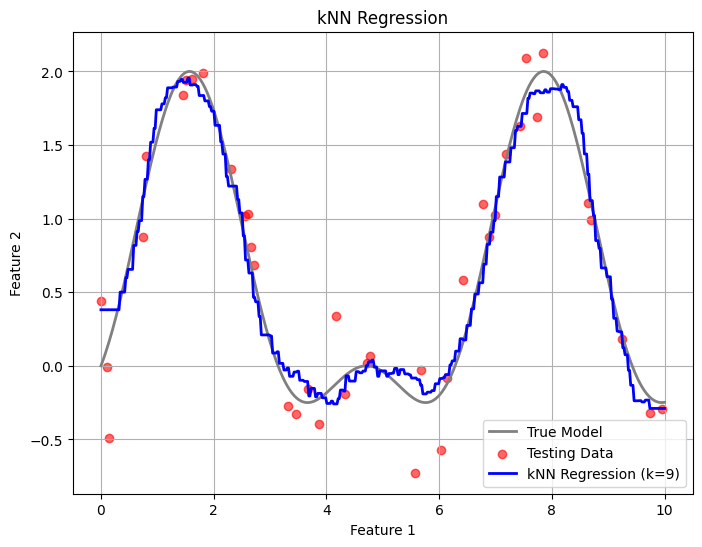

In [14]:
y_pred_knn = final_knn_regressor.predict(X_range.reshape(-1, 1))

plt.figure(figsize=(8, 6))
plt.plot(X_range, y_truth, label=f'True Model', color='grey', linewidth=2)
plt.scatter(X_test, y_test, label='Testing Data', color='red', alpha=0.6)
plt.plot(X_range, y_pred_knn, label=f'kNN Regression (k={best_k})', color='blue', linewidth=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('kNN Regression')
plt.grid(True)
plt.show()


Notice that the kNN model performs well, but does not provide a smooth function at all. At the curves and endpoints, we see the model is very sensitive to noise. 